# Loan Prediction Using Feature Engineering Pipelines

This notebook demonstrates a production-style machine learning workflow using sklearn Pipelines and ColumnTransformer.

Goals:

- Build a baseline preprocessing pipeline
- Evaluate multiple feature engineering techniques
- Measure their impact on model performance
- Document findings for reproducible machine learning workflows

## Objective

This notebook demonstrates how feature engineering impacts model performance on the Loan Prediction dataset using a reproducible sklearn preprocessing pipeline.

Workflow:

1. Build baseline pipeline
2. Evaluate baseline model
3. Apply feature engineering techniques
4. Measure performance impact
5. Compare results
6. Draw conclusions

Model:
- Logistic Regression

Preprocessing:
- Median Imputation
- Most Frequent Imputation
- OneHotEncoding
- PowerTransformer
- StandardScaler

In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay

In [122]:
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

In [123]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [124]:
df.drop_duplicates(inplace=True)

In [125]:
X = df.drop('Loan_Status',axis = 1)
le = LabelEncoder()
y = le.fit_transform(df['Loan_Status'])

In [126]:
y

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,

In [127]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42
                                                 )

In [128]:
X_train.shape,X_test.shape

((491, 12), (123, 12))

In [129]:
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Dependents']
categorical_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

In [130]:
class LoanFeatureEditer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Fix Dependents — future data will also have '3+'
        X['Dependents'] = X['Dependents'].replace('3+', 3).astype(float)

        return X

In [131]:
num_pipeline = Pipeline([
    ('Imputer',SimpleImputer(strategy='median')),
    ('power_transformer',PowerTransformer(method='yeo-johnson')),
    ('scaler',StandardScaler())
])

In [132]:
from warnings import simplefilter
cat_pipeline = Pipeline([
    ('cat_imputer',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=True))
])

In [133]:
preprocesser = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
], remainder='drop') # Drop any columns not specified, like 'Loan_ID'

In [134]:
pipeline = Pipeline([
    ('feature_edit',LoanFeatureEditer()),
    ('preprocesser',preprocesser),
    ('model',LogisticRegression())
])

In [135]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_edit', LoanFeatureEditer()),
                ('preprocesser',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transformer',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Dependents']),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area'])])),
                ('model', LogisticRegression())])

In [136]:
y_pred = pipeline.predict(X_test)

In [137]:
base_acc = accuracy_score(y_test,y_pred)
print("Accuracy:",base_acc)

Accuracy: 0.7886178861788617


In [138]:
print('Classification Report:\n\n',classification_report(y_test,y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



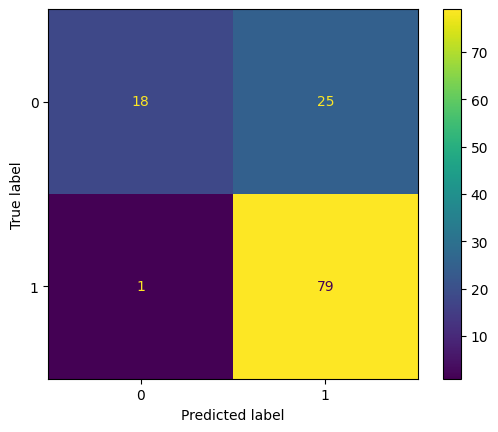

In [139]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

# **Feature Engineering Experiment**

In [140]:
class LoanFeatureCreator(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Fix Dependents — future data will also have '3+'
        X['Dependents'] = X['Dependents'].replace('3+', 3).astype(float)

        # Create new features
        X['TotalIncome'] = X['ApplicantIncome'] + X['CoapplicantIncome']
        X['LoanIncomeRatio'] = X['LoanAmount'] / (X['TotalIncome'] + 1)


        return X



In [141]:
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Dependents','TotalIncome','LoanIncomeRatio']
categorical_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

In [142]:
preprocessor_feat = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

In [143]:
pipeline_feat = Pipeline([
    ('feature_creator', LoanFeatureCreator()),
    ('preprocessor', preprocessor_feat),
    ('model', LogisticRegression())
])

In [144]:
pipeline_feat.fit(X_train,y_train)

Pipeline(steps=[('feature_creator', LoanFeatureCreator()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transformer',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History',
                                                   'Dependents', 'TotalIncome',
                                                   'LoanIncomeRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Married',
                                                   'Education', 'Self_Employed',
                                                   'Property_Area'])])),
                ('model', LogisticRegression())])

In [145]:
y_pred = pipeline_feat.predict(X_test)

In [146]:
feat_acc = accuracy_score(y_test,y_pred)
print("Accuracy:",feat_acc)

Accuracy: 0.7886178861788617


In [147]:
print('Classification Report:\n\n',classification_report(y_test,y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



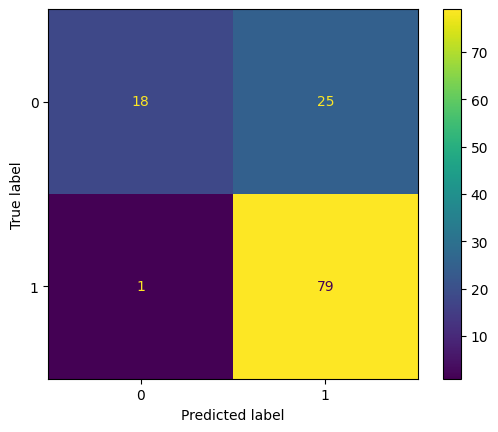

In [148]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [149]:
results = pd.DataFrame({
    'Experiment':[
        'Baseline',
        'column_created'

    ],
    'Accuracy':[
        base_acc,
        feat_acc
    ]
})

In [150]:
results['Improvement'] = (
    results['Accuracy'] - base_acc
)


In [151]:
results

,Experiment,Accuracy,Improvement
0,Baseline,0.788618,0.0
1,column_created,0.788618,0.0


# Feature Engineering Experiment Summary

Two model versions were evaluated:

## Baseline Model

The baseline model was trained using the original dataset features and a preprocessing pipeline consisting of:

- Missing value imputation
- Categorical encoding
- Numerical scaling
- Logistic Regression classifier

## Feature Engineered Model

Additional engineered features were introduced to capture more meaningful business information from the original variables.

Examples include:

- TotalIncome
- LoanIncomeRatio
- Other derived features

The same preprocessing and modeling workflow was applied to ensure a fair comparison.

## Objective

The purpose of this experiment was to determine whether engineered features provide additional predictive information beyond the original dataset.

# Final Conclusions

## Key Findings

1. A complete machine learning pipeline was successfully built using sklearn Pipeline and ColumnTransformer.

2. Missing values, categorical variables, and numerical variables were automatically processed within the pipeline.

3. Feature engineering was performed based on insights obtained during exploratory data analysis.

4. Model performance was evaluated using:
   - Accuracy Score
   - Classification Report
   - Confusion Matrix

5. Baseline and feature-engineered models were compared to measure the impact of newly created features.

## Business Insights

- Credit history remains one of the strongest indicators of loan approval.
- Income-related features provide useful information for assessing repayment capability.
- Engineered features can improve the model's ability to identify approved and rejected applications.

## Final Outcome

This workflow demonstrates a complete end-to-end machine learning process:

EDA
→ Feature Engineering
→ Preprocessing Pipeline
→ Model Training
→ Evaluation
→ Feature Impact Analysis

The dataset is now processed using a reusable and production-style machine learning pipeline.